In [1]:
# jax ecosystem
import jax

jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_enable_x64", True)
print(jax.local_devices()[0].device_kind)

from jax import numpy as np, tree as jtu
import zodiax as zdx
from zodiax.optimisation import sgd, adam
import amigo
import dorito

# other helpful libraries
import numpy
import os
import astropy

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots  # to use matplotlib style "science"

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/code/amigo/src/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
elif gethostname() == "AJQ4YHQH9TX":
    path = "/Volumes/morgana1/snert/max/"
else:
    path = "/fred/oz440/max/"

source_name = "PDS70"
data_path = os.path.join(path, f"data/JWST/{source_name}/calslope/")
uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
amigo_cache = os.path.join(path, "data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)


# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    if file[0].header["TARGPROP"] == "TD-PDS-70":
        # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
        file["BADPIX"].data[17, 70] = 1
        file["BADPIX"].data[19, 53] = 1
        file["BADPIX"].data[5, 22] = 1
        file["BADPIX"].data[19, 41] = 1
        # file["BADPIX"].data[:66, :25] = 1  # BACKGROUND STAR?
        file["BADPIX"].data[76, 45] = 1
        file["BADPIX"].data[59, 30] = 1

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(sci_files, 30)

In [4]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}, PWCPOS {h["PWCPOS"]}'
    )
    t0 = t


------------------------------

HD 228337 F480M, Dither 1/1, Roll 302.2deg, 15.2min, 2023-02-24 19:20:07.785, Groups: 29, Ints: 418, PWCPOS 205.0233309999992
TD-PDS-70 F480M, Dither 1/1, Roll 301.7deg, 50.5min, 2023-02-24 21:05:08.000, Groups: 96, Ints: 418, PWCPOS 204.98422199999922


/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


## Building the model

In [5]:
from amigo.model_fits import ModelFit
from amigo.vis_models import vis_to_im
from amigo.vis_analysis import AmigoOIData
from amigo.misc import interp
from jax import lax, numpy as np
import dLux as dl
import dLux.utils as dlu
import equinox as eqx
from dorito.model_fits import BaseResolvedFit


class MultiSourceFit(ModelFit):

    exposures: dict
    calibrator: bool = None  # this will mean multi fit
    unique_params: list = None

    def __init__(self, file, exp_dict, unique_params=None):

        super().__init__(file)

        for source_id, exp in exp_dict.items():
            if not isinstance(exp, ModelFit):
                raise ValueError(
                    f"All exposures must be ModelFit instances, got {type(exp)} for source_id {source_id}."
                )

        # Assert all exposures have the same filter
        filenames = [exp.filename for exp in exp_dict.values()]
        assert len(set(filenames)) == 1

        self.exposures = exp_dict
        self.calibrator = None  # this will mean multi fit
        if unique_params is None:
            unique_params = [
                "positions",
                "fluxes",
                "spectra",
                "log_dist",
                "contrast",
            ]
        self.unique_params = unique_params

    def get_key(self, param, source_id=None):

        if source_id is None:
            print("Warning: source_id is None in get_key, taking the first exposure.")
            source_id = list(self.exposures.keys())[0]

        exp = self.exposures[source_id]

        if param in self.unique_params:
            return "_".join([exp.get_key(param), source_id])

        return exp.get_key(param)

    def map_param(self, param, source_id=None):

        if source_id is None:
            print("Warning: source_id is None in map_param, taking the first exposure.")
            source_id = list(self.exposures.keys())[0]

        # Map the appropriate parameter to the correct key
        if param in self.unique_params:
            return f"{param}.{self.get_key(param, source_id)}"

        # Else its global
        return self.exposures[source_id].map_param(param)

    def get_spectra(self, model, source_id):
        wavels, filt_weights = model.filters[self.filter]
        xs = np.linspace(-1, 1, len(wavels), endpoint=True)
        spectra_slopes = 1 + model.get(self.map_param("spectra", source_id)) * xs
        weights = filt_weights * spectra_slopes
        weights = np.where(weights < 0, 0.0, weights)
        return wavels, weights / weights.sum()

    def model_wfs(self, model, source_id):
        pos = dlu.arcsec2rad(model.positions[self.get_key("positions", source_id)])
        wavels, weights = self.get_spectra(model, source_id)

        optics = self.update_optics(model, source_id)
        wfs = eqx.filter_jit(optics.propagate)(wavels, pos, weights, return_wf=True)

        # Convert Cartesian to Angular wf
        if wfs.units == "Cartesian":
            wfs = wfs.multiply("pixel_scale", 1 / optics.focal_length)
            wfs = wfs.set(["plane", "units"], ["Focal", "Angular"])
        return wfs

    def model_psf(self, model, source_id):
        wfs = self.model_wfs(model, source_id)
        return dl.PSF(wfs.psf.sum(0), wfs.pixel_scale.mean(0))

    def model_illuminance(self, psf, model, source_id):
        flux = self.ngroups * 10 ** model.fluxes[self.get_key("fluxes", source_id)]
        psf = eqx.filter_jit(model.detector.apply)(psf)
        return psf.multiply("data", flux)

    def update_optics(self, model, source_id):
        optics = model.optics
        if "aberrations" in model.params.keys():
            coefficients = model.aberrations[self.get_key("aberrations", source_id)]

            # Nuke the piston gradient to prevent degeneracy
            fixed_piston = lax.stop_gradient(coefficients[0, 0])
            coefficients = coefficients.at[0, 0].set(fixed_piston)

            # Stop gradient for science targets
            if not self.calibrator:
                coefficients = lax.stop_gradient(coefficients)
            optics = optics.set("pupil_mask.abb_coeffs", coefficients)

        if hasattr(model, "reflectivity"):
            coefficients = model.reflectivity[self.get_key("reflectivity", source_id)]
            optics = optics.set("pupil_mask.amp_coeffs", coefficients)

        # Set the defocus
        optics = optics.set(
            "defocus", model.defocus[self.get_key("defocus", source_id)]
        )

        return optics

    def simulate(self, model, return_slopes: bool = True, **kwargs):

        # model/propagate the PSF of each source separately!
        illuminances = []
        for source_id, exp in self.exposures.items():
            psf = self.model_psf(model, source_id)
            if isinstance(exp, BaseResolvedFit):
                image = exp.model_interferogram(
                    psf, model, source_id=source_id, **kwargs
                )
            else:
                image = psf
            image = image.downsample(model.source_oversample)
            illuminance = self.model_illuminance(image, model, source_id)
            illuminances.append(illuminance.data)

        illuminance = dl.PSF(np.array(illuminances).sum(axis=0), image.pixel_scale)

        # Just grab any old exposure to get the detector methods
        exp = list(self.exposures.values())[0]
        ramp = exp.model_ramp(illuminance, model)
        ramp = exp.model_read(ramp, model)

        if return_slopes:
            return ramp.set("data", np.diff(ramp.data, axis=0))
        return ramp

    # def rotate(self, distribution, clip=True, interp_method="linear"):
    #     pass

    def print_summary(self):
        for source_id, exp in self.exposures.items():
            print(f"Source ID: {source_id}")
            exp.print_summary()
            print()

    def rotate(self, distribution, clip=True, interp_method="linear", source_id=None):
        if source_id is None:
            print("Warning: source_id is None in rotate, taking the first exposure.")
            source_id = list(self.exposures.keys())[0]

        exposure = self.exposures[source_id]

        return exposure.rotate(distribution, clip, interp_method)

    # def __getattr__(self, name):
    #     # called only if attribute not found normally
    #     print(f"Delegating {name} to inner B")
    #     return getattr(list(self.exposures.values())[0], name)

    def __call__(self, model, return_slopes=True):
        return self.simulate(model, return_slopes=return_slopes).data

In [6]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# just two science exposures and one calibrator for this demo
# sci_exps = [PointResolvedFit(file) for file in sci_files]
exp_dict = {
    "TD": dorito.model_fits.PointResolvedFit(sci_files[0]),
    #     # "STAR": amigo.model_fits.PointFit(sci_files[0]),
    #     # "TD": dorito.model_fits.TransformedResolvedFit(sci_files[0]),
    "FS": amigo.model_fits.PointFit(sci_files[0]),
}
sci_exps = [MultiSourceFit(sci_files[0], exp_dict)]
cal_exps = [amigo.model_fits.PointFit(file) for file in cal_files]
exps = sci_exps + cal_exps
# exps = cal_exps
# exps = sci_exps

# building the model
source_size = 81  # pixels
basis, window = dorito.bases.inscribed_annulus_basis(source_size, iterations=1)
init_dist = np.ones((source_size, source_size)) / window.sum()
model = dorito.models.TransformedResolvedModel(
    exposures=exps,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    state=load_dict(cache + "calibration.npy"),
    basis=basis,
    window=window,
    param_initers={"contrast": 0.04, "distribution": init_dist},
)

# model.params["aberrations"] = load_dict("files/PDS70_CALFIT.npy")["aberrations"]
model.params["positions"]["01242_005_02_03_1_FS"] = np.array([-2.15, -0.71])
model.params["fluxes"]["01242_005_02_03_1_FS"] = np.array([2.5])
# model.params["fluxes"]["01242_005_02_03_1_TD"] = (
#     np.log10(0.04) + model.params["fluxes"]["01242_005_02_03_1_STAR"]
# )

Source ID: TD
File 01242_005_02_03_1
Star TD-PDS-70
Filter F480M
nints 418
ngroups 96


Source ID: FS
File 01242_005_02_03_1
Star TD-PDS-70
Filter F480M
nints 418
ngroups 96




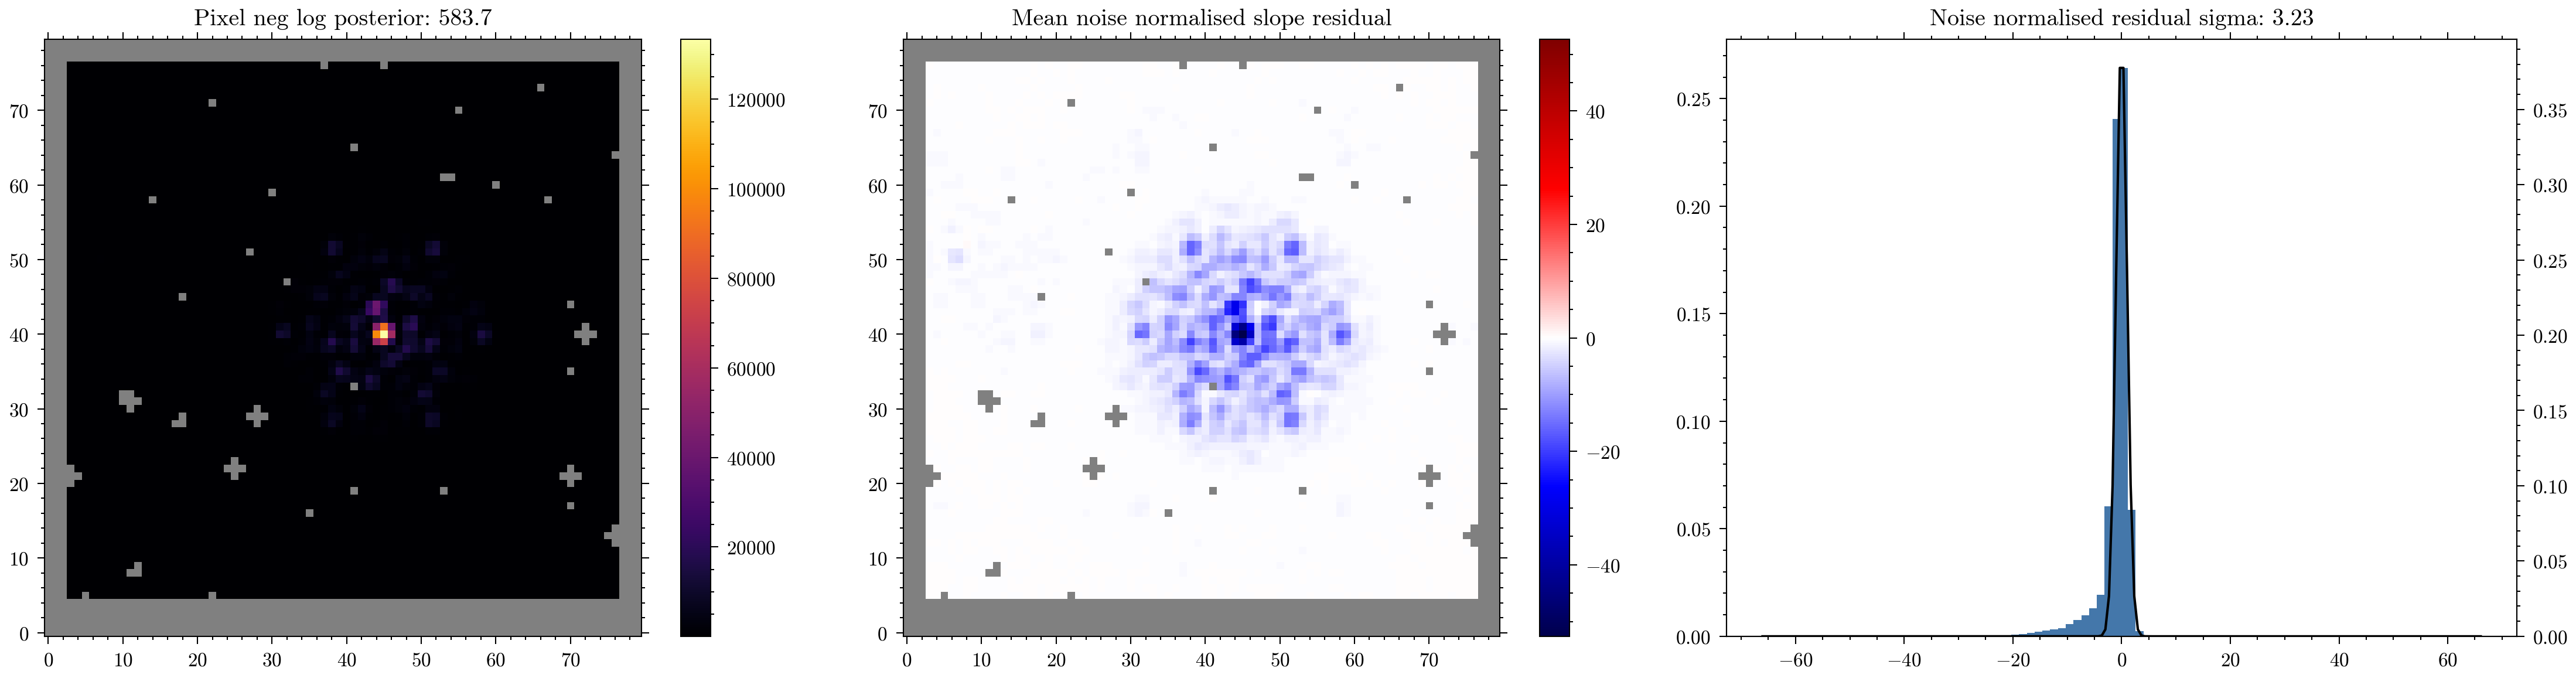

File 01242_004_02_03_1
Star HD 228337
Filter F480M
nints 418
ngroups 29



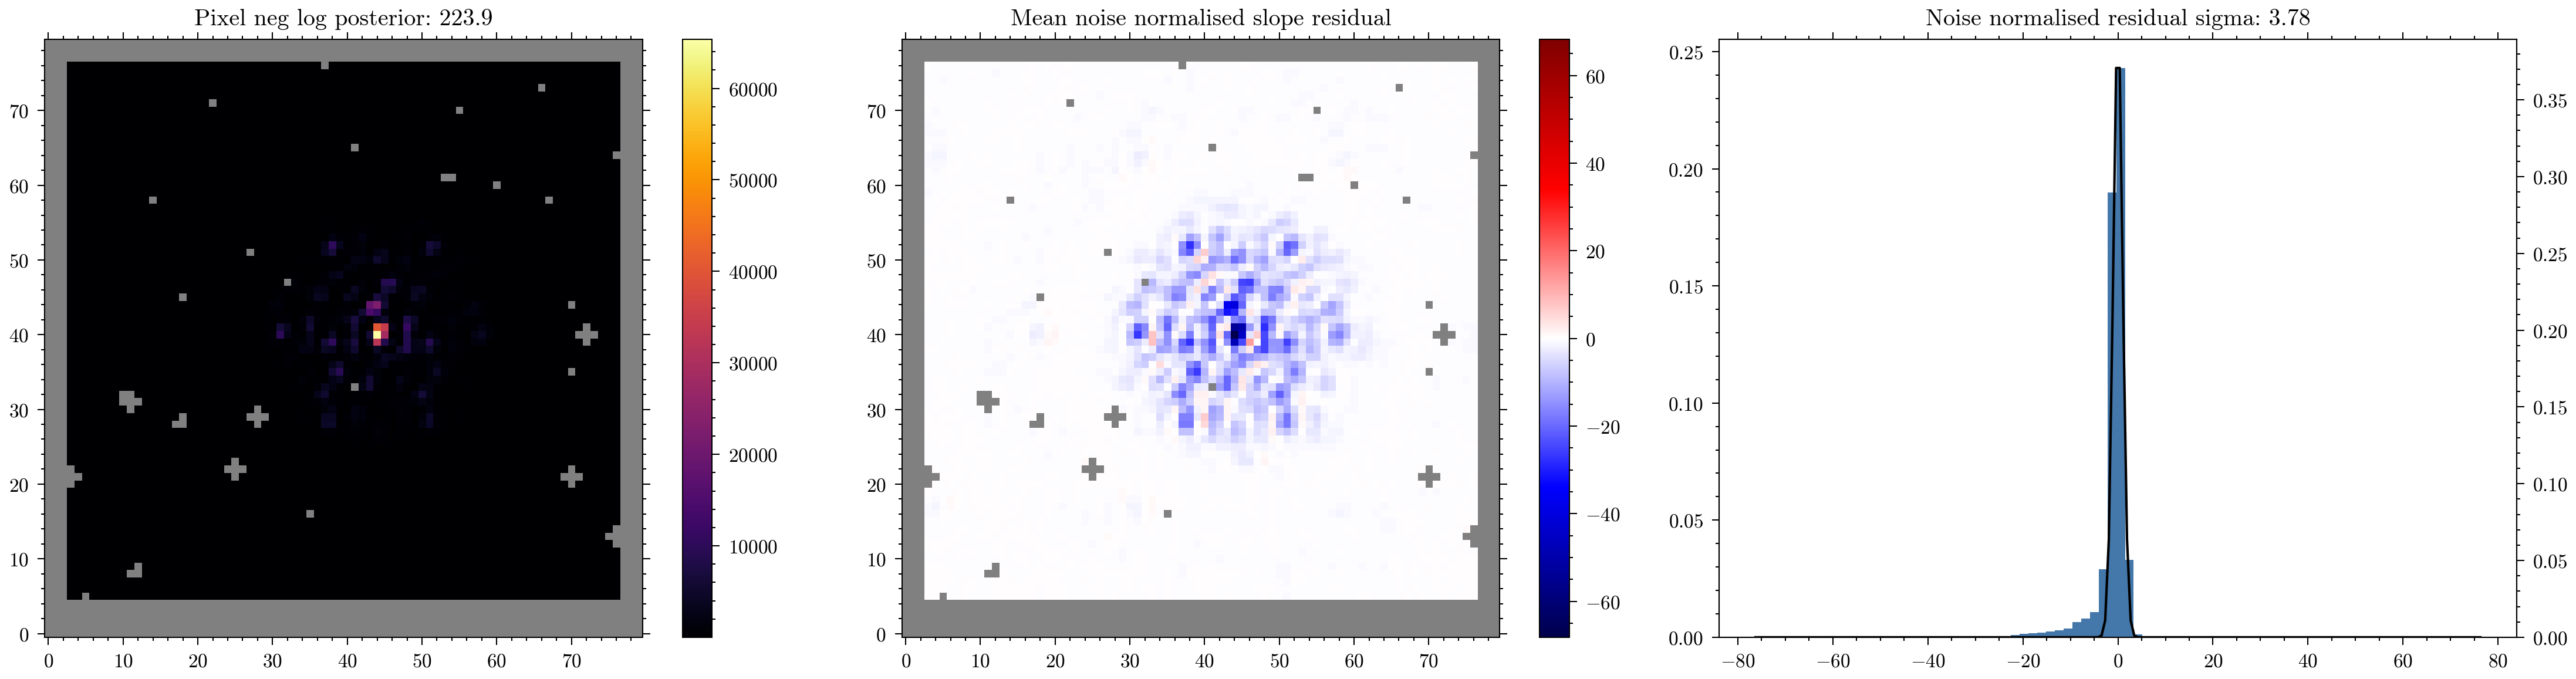

In [7]:
for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp, residuals=False)

## Optimisation Stage 1: Gradient Descent

In [ ]:
pos_keys = []
spc_keys = []
flx_keys = []
for exp in exps:
    if not exp.calibrator:
        spc_keys.append(exp.map_param("spectra", "TD"))
        spc_keys.append(exp.map_param("spectra", "FS"))
        pos_keys.append(exp.map_param("positions", "FS"))
        pos_keys.append(exp.map_param("positions", "TD"))
        flx_keys.append(exp.map_param("fluxes", "TD"))


from jax_gaussian import gaussian_filter

sig = 0.25


def norm_fn(model_params, args):
    params = model_params.params

    # NOTE: This normalisation won't work for an arbitrary basis!
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist
            log_dist = np.log10(distribution / distribution.sum())

            # basis = args["basis"]
            # window = args["window"]
            # distribution = 10 ** basis.from_basis(log_dist) * window
            # distribution = gaussian_filter(distribution, sigma=sig)
            # distribution += 1e-16 * ((window + 1) % 2)
            # log_dist = np.log10(distribution / distribution.sum())
            # log_dist = basis.to_basis(log_dist)
            params["log_dist"][k] = log_dist

    if "spectra" in params.keys():
        spectra = jax.tree.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args


pscale = lambda model: model.optics.psf_pixel_scale / model.optics.oversample

In [22]:
n_epoch = 40

schedule = {
    "fluxes": 0,
    "positions": 20,
    "aberrations": 40,
    "spectra": 60,
    "contrast": 80,
    "distribution": 100,
}

config = {
    "positions": sgd(3e-2, schedule["positions"]),
    "fluxes": sgd(2e-2, schedule["fluxes"]),
    # "aberrations": sgd(2e-2, schedule["aberrations"]),
    # "spectra": sgd(4e-2, schedule["spectra"]),
    # "log_dist": adam(2e-1, schedule["distribution"]),
    # # # "log_dist": adam(5e-1, 30),
    # "contrast": adam(2e-2, schedule["contrast"]),
    # "log_dist": adam(5e-2, 0),
    # "fluxes": sgd(2e-2, 0),
}


def grad_fn(model, grads, args):

    # Reduce spectra gradients for the science exposures
    # if "spectra" in config.keys():
    #     grads = grads.multiply(spc_keys, 0.3)

    # if "fluxes" in config.keys():
    #     grads = grads.multiply(flx_keys, 0.01)

    if "positions" in config.keys():
        grads = grads.multiply(pos_keys, 0.1)

    return grads, args


args = {
    "reg_dict": {
        # "ME": (5e-2, dorito.stats.ME),
        "TV": (3e-2, dorito.stats.TV),
        # "TV": (1e14, logTV),
    },
    "source_id": "TD",
    # "basis": basis,
    # "window": window,
}

trainer = amigo.fitting.Trainer(
    loss_fn=dorito.stats.ramp_regularised_loss_fn,
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)

print("Populating fishers...")
trainer = trainer.populate_fishers(
    model,
    exps,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=[p for p in config.keys() if p not in ["log_dist", "contrast"]],
)

print("Number of exposures: ", len(exps))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exps,
    args=args,
)

Populating fishers...
Number of exposures:  2


  0%|          | 0/40 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 381.92
Estimated run time: 0:00:50
Full Time: 0:01:15
Final Loss: 43.80


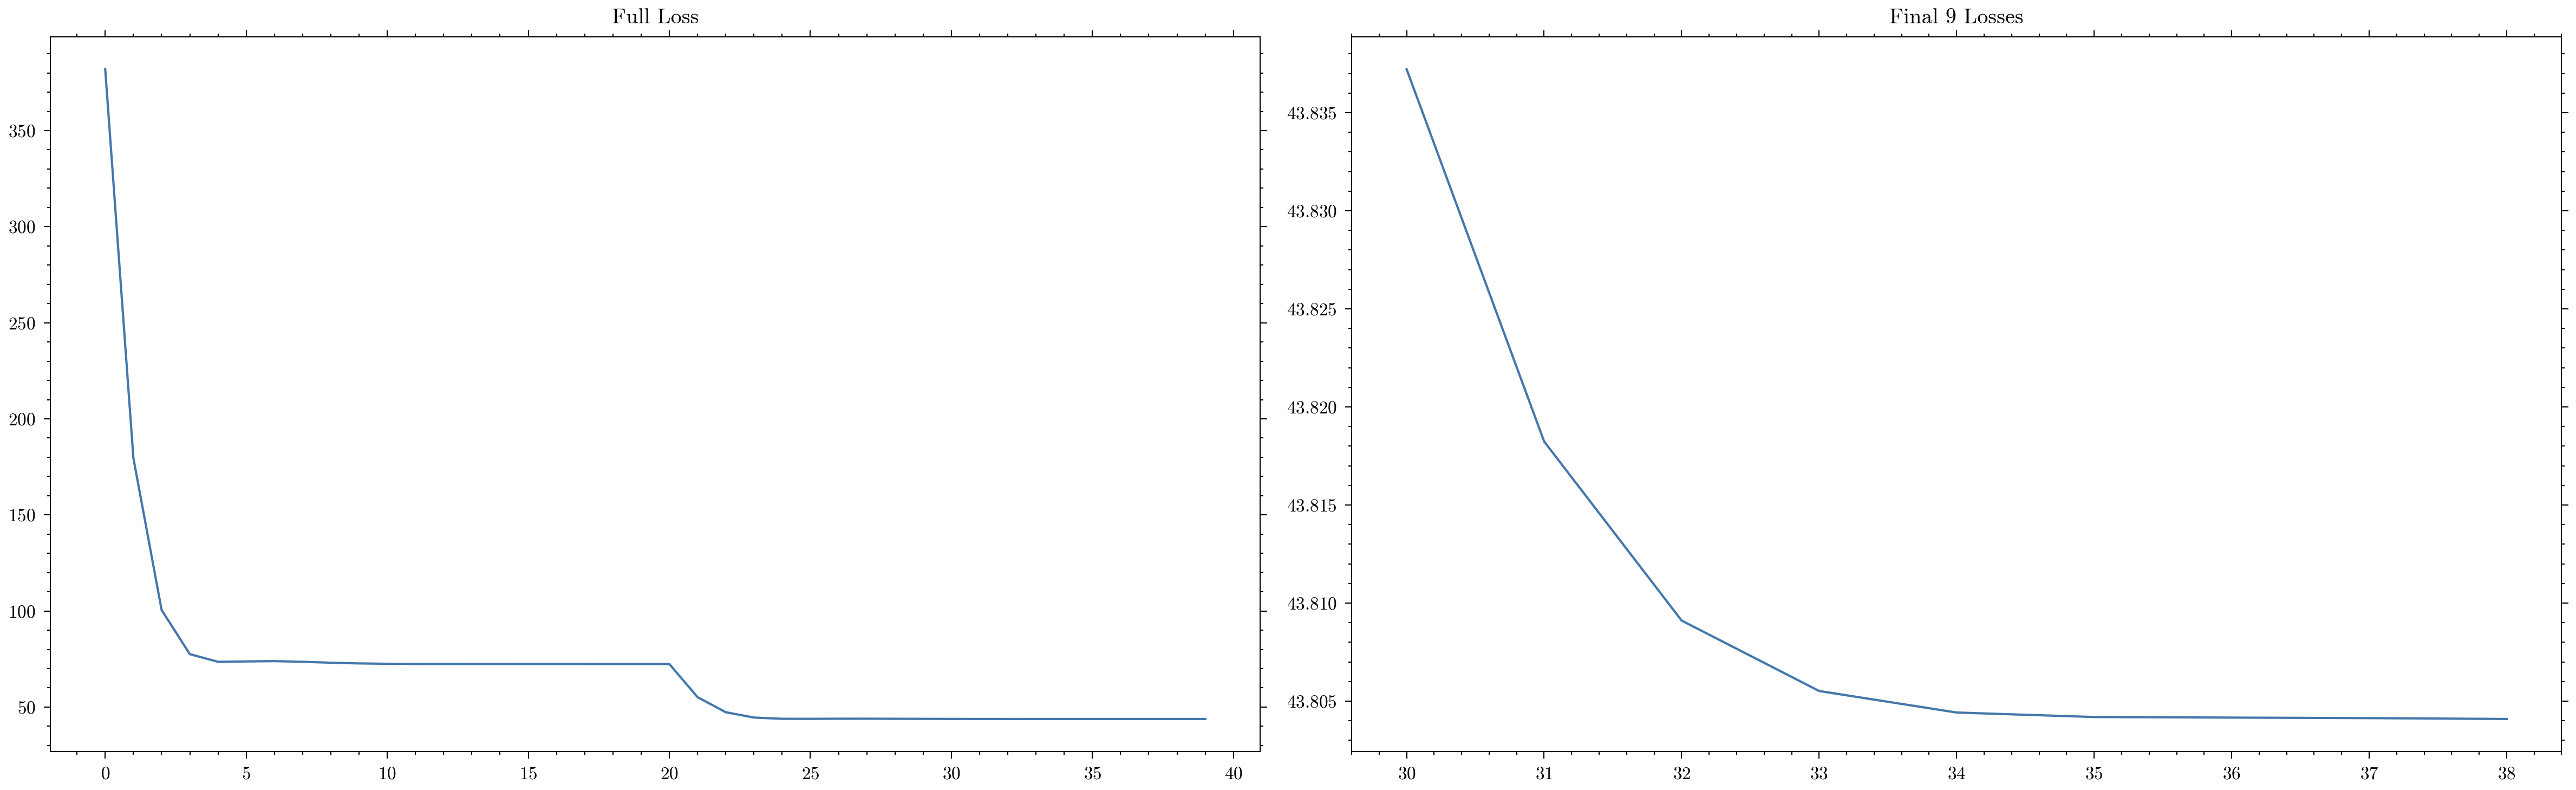

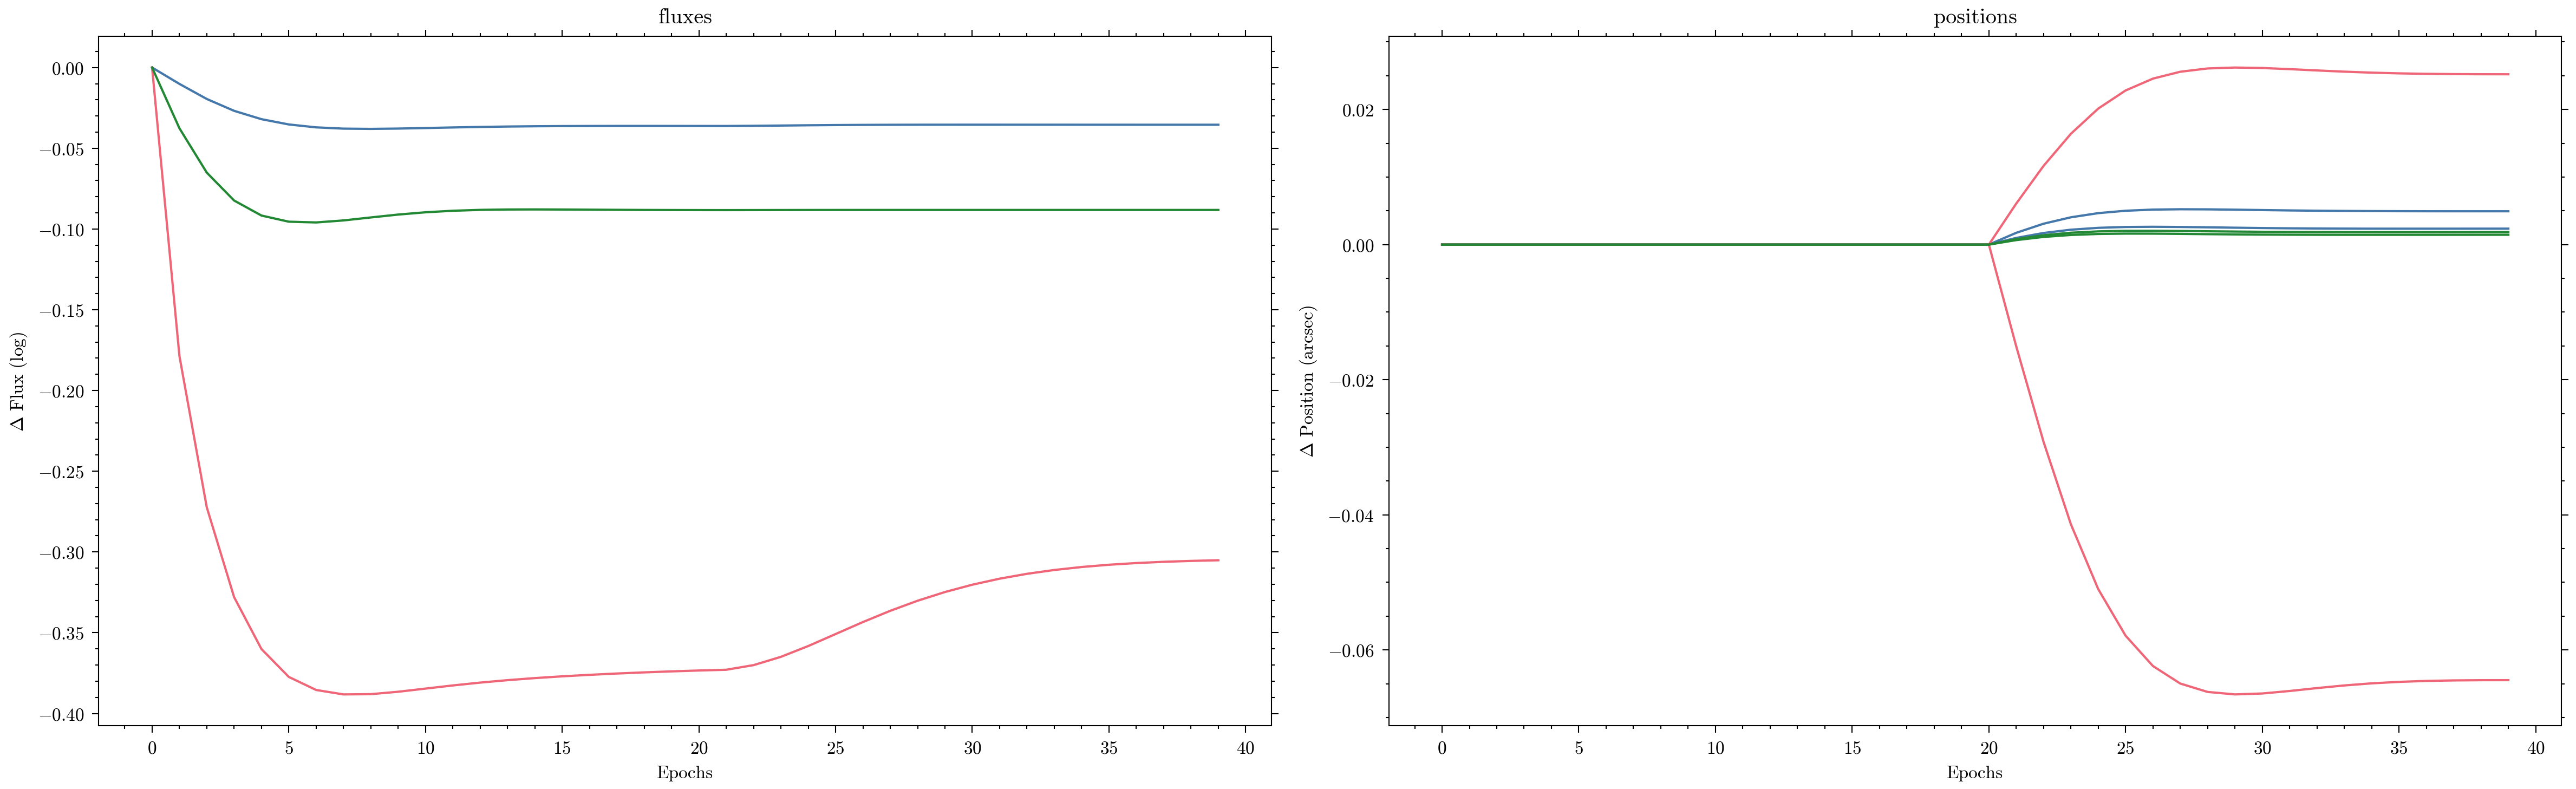

Source ID: TD
File 01242_005_02_03_1
Star TD-PDS-70
Filter F480M
nints 418
ngroups 96


Source ID: FS
File 01242_005_02_03_1
Star TD-PDS-70
Filter F480M
nints 418
ngroups 96




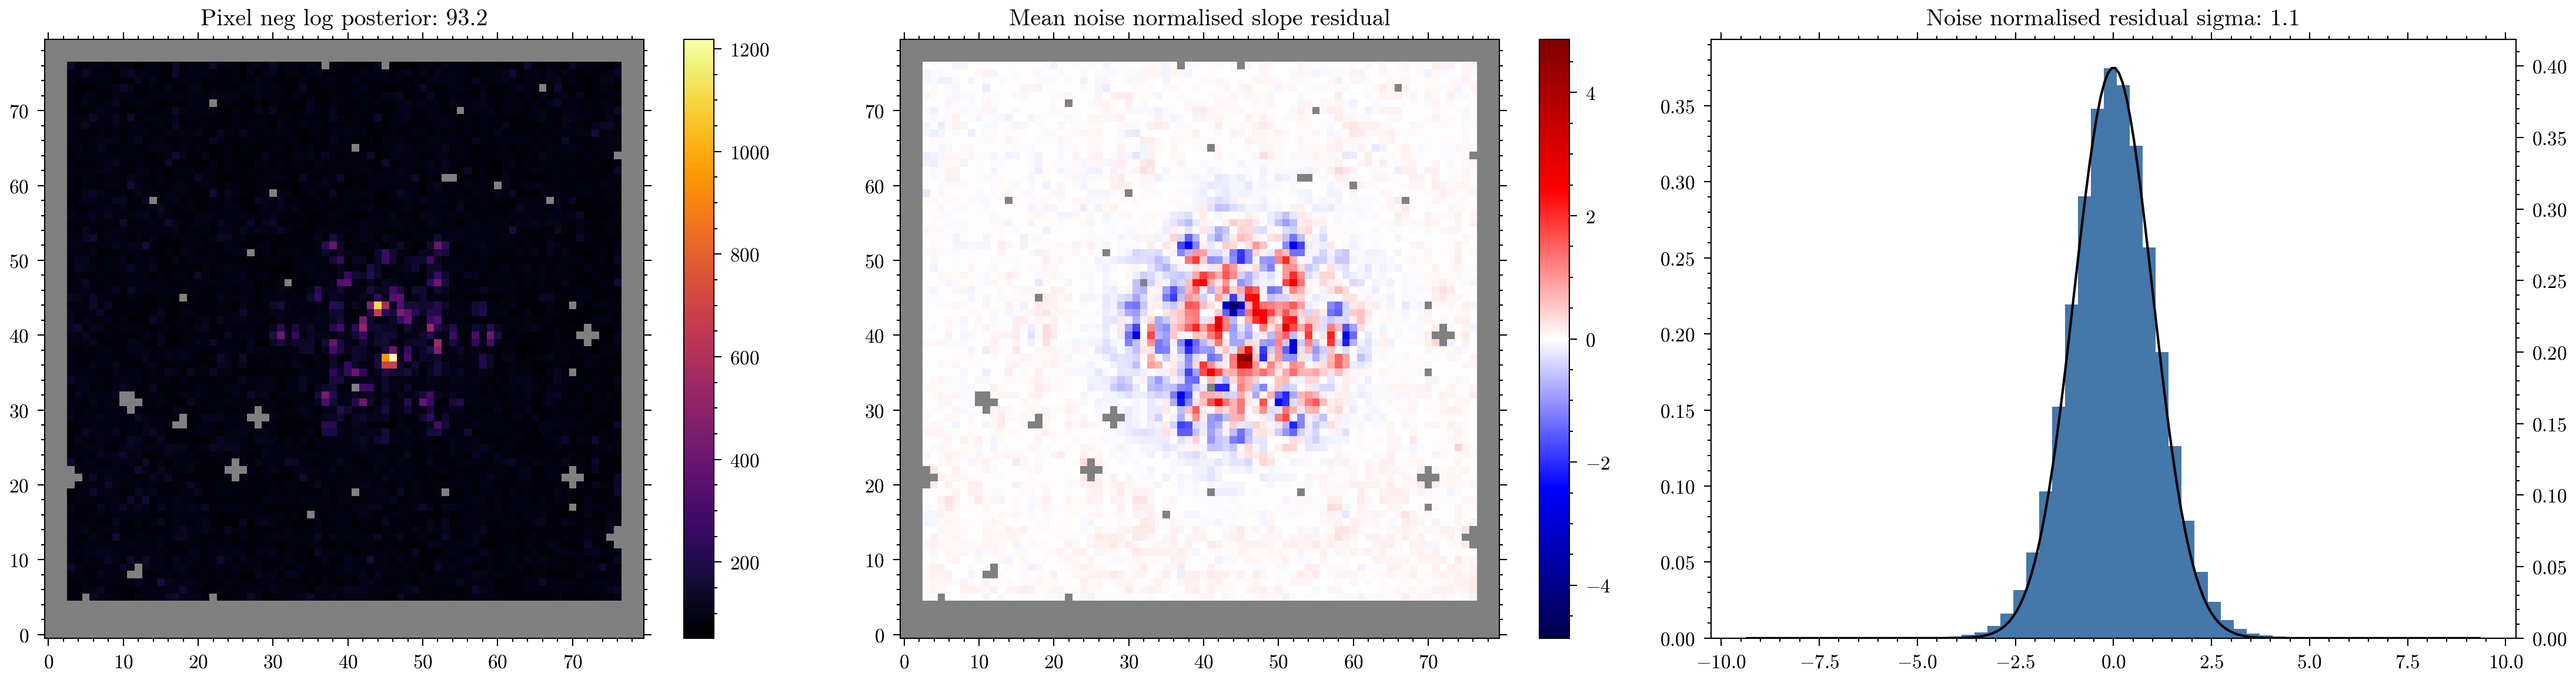

File 01242_004_02_03_1
Star HD 228337
Filter F480M
nints 418
ngroups 29



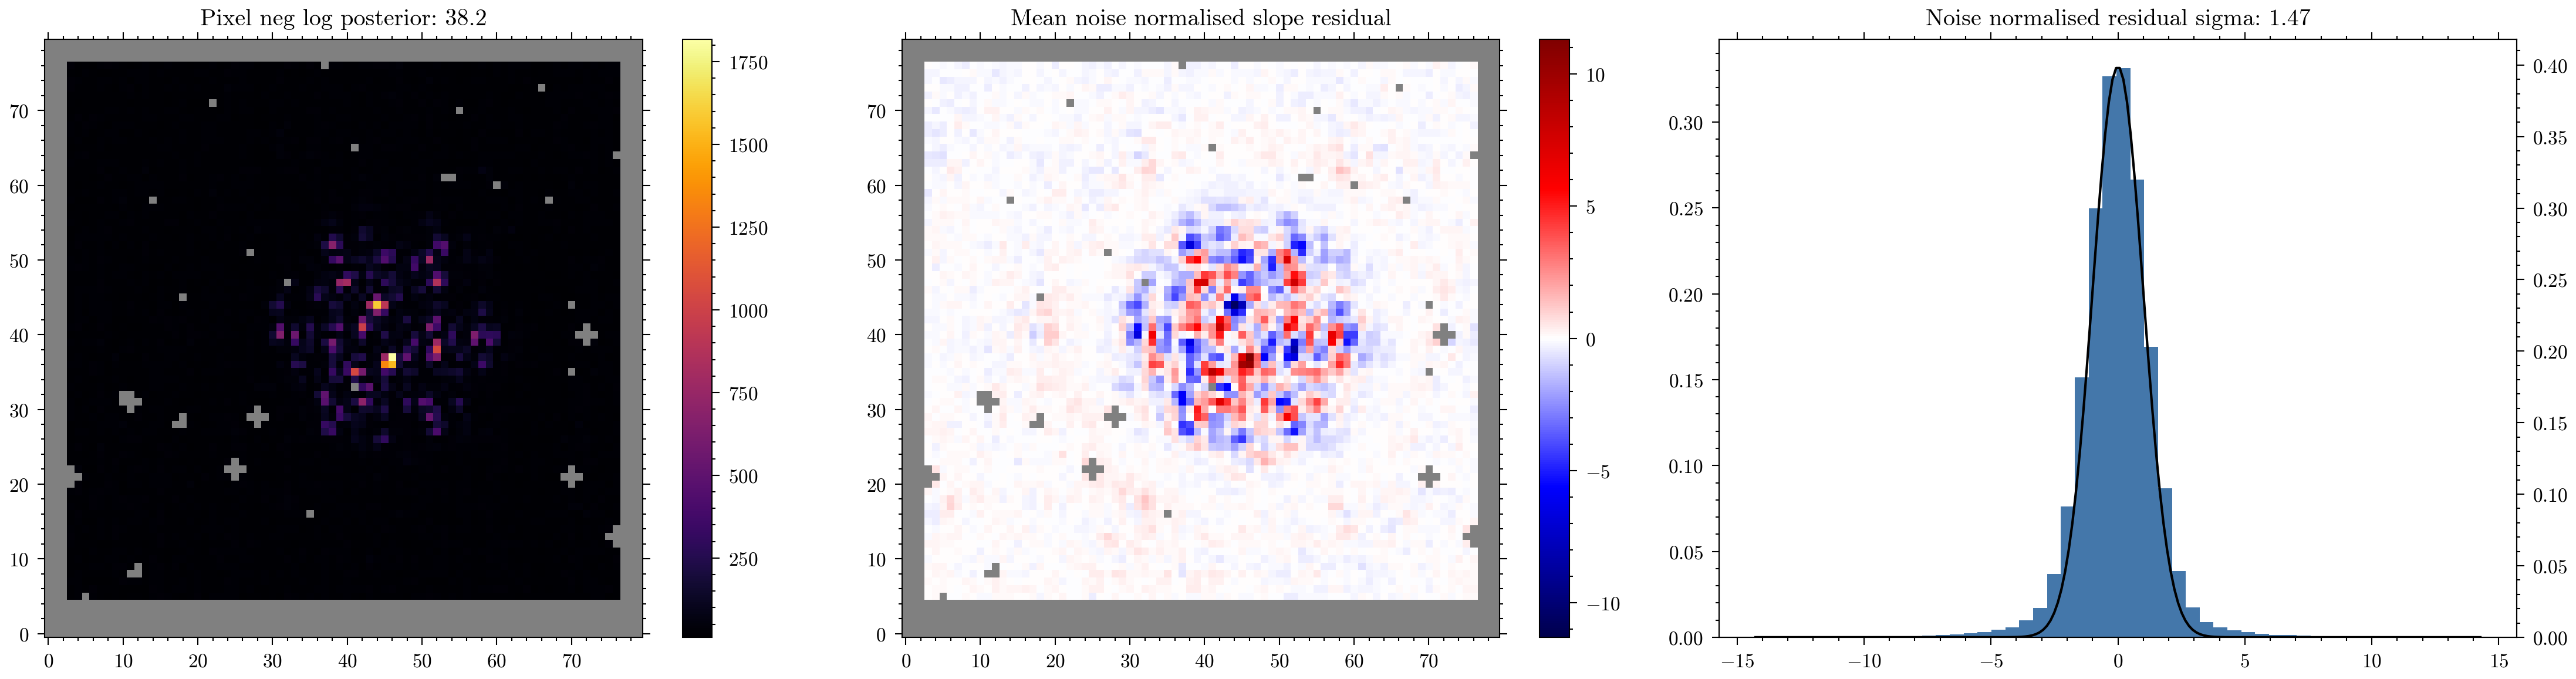

In [23]:
amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

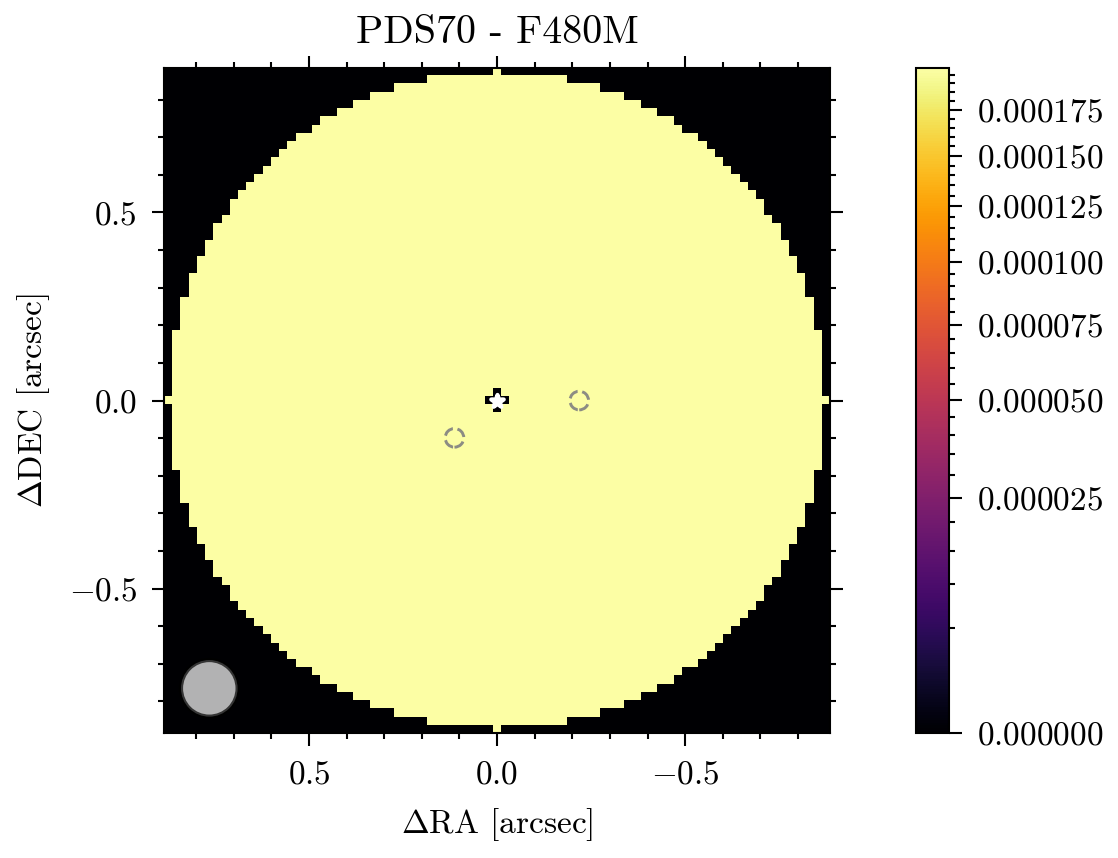

In [11]:
from dLux import utils as dlu

# np.save("files/pds70_abs.npy", result.model.params["aberrations"], allow_pickle=True)


def eff_wavel(model, filt):
    wavels, weights = model.filters[filt]
    return np.dot(wavels, weights)


result_model = result.model
optics_diameter = 6.603464  # JWST aperture diameter in meters

for exp in exps:

    if exp.calibrator:
        continue
    dist = result_model.get_distribution(
        exp.exposures["TD"], rotate=False, source_id="TD"
    )
    fig, ax = plt.subplots(figsize=(6, 3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="inferno",
        # roll_angle_degrees=-exp.parang,
        norm=mpl.colors.PowerNorm(0.5, vmin=None),
        # norm=mpl.colors.PowerNorm(0.3, vmax=0.3),
        diff_lim=0.5 * dlu.rad2arcsec(eff_wavel(model, exp.filter) / optics_diameter),
        # scale=1.5,
    )

    fig.colorbar(c0)

    ax.set(title=f"PDS70 - {exp.filter}")  #   xticks=ticks, yticks=ticks)
    ax.scatter([0], [0], marker="*", color="white", s=10)

    seps = 1e-3 * np.array([150.5, 218.4])
    pas = np.array([131.2, 270.0])
    xs = seps * np.cos(np.radians(pas))
    ys = seps * np.sin(np.radians(pas))
    ax.scatter(
        ys,
        xs,
        marker="o",
        alpha=0.9,
        s=20,
        facecolors="none",
        edgecolors="grey",
        linestyle="--",
        linewidths=0.7,
    )

    plt.tight_layout()
    plt.show()
    # plt.savefig(output_path + f"{exp.key}_dist.png", dpi=300)

  0%|          | 0/50 [00:00<?, ?it/s]

KeyError: 'aberrations'

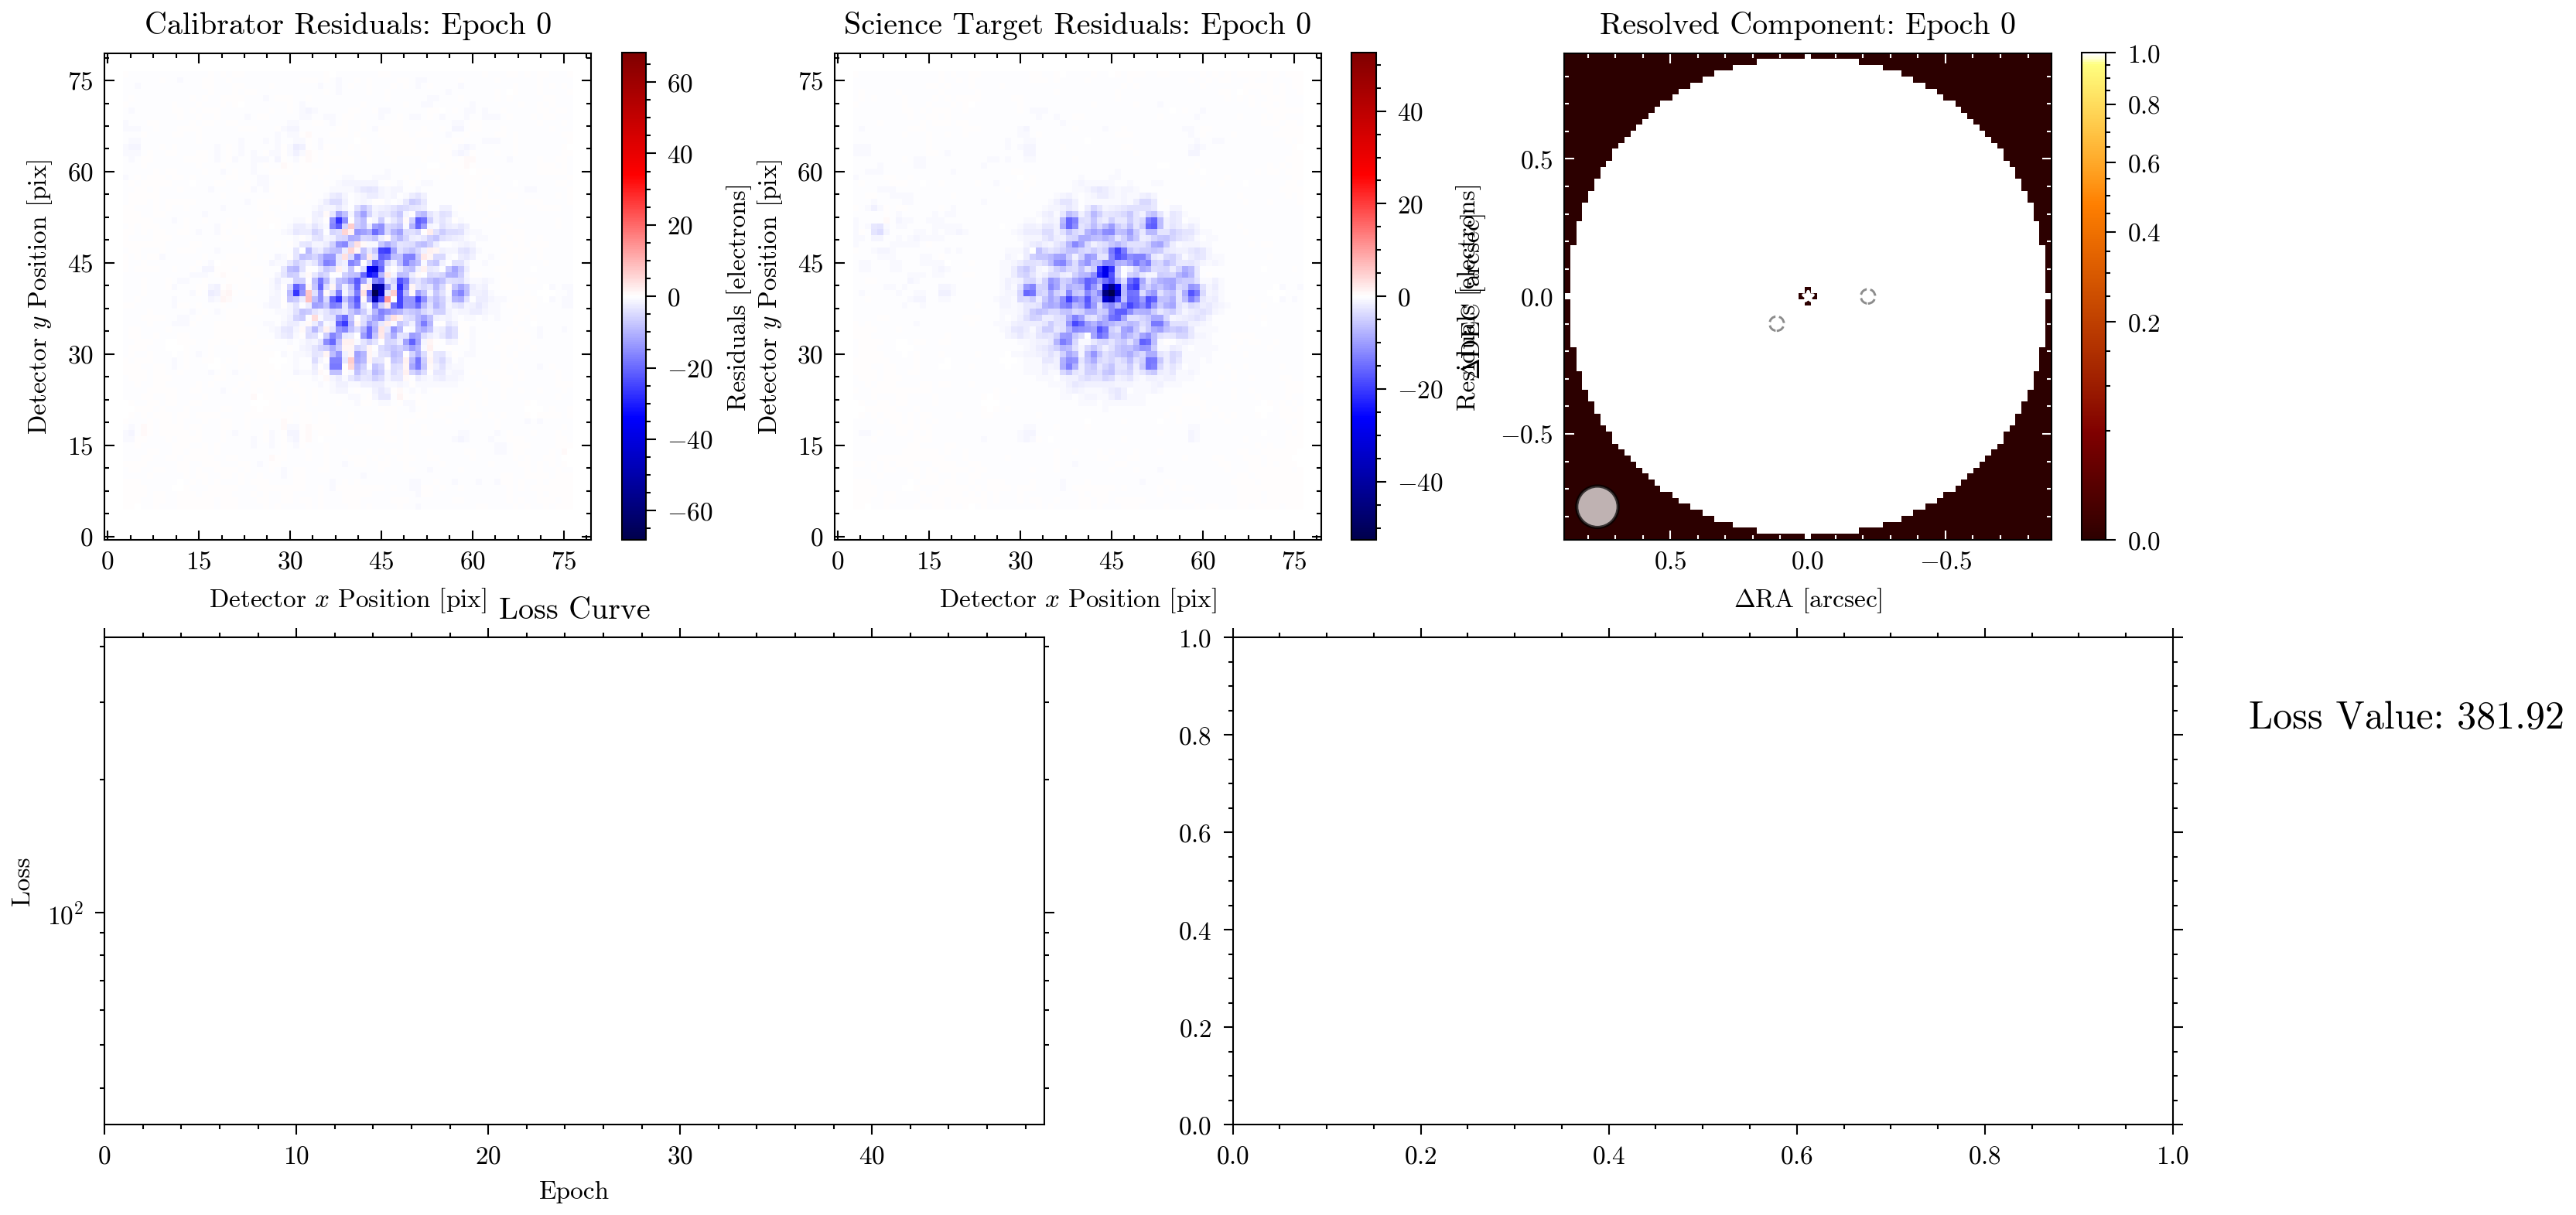

In [12]:
from tqdm.notebook import tqdm

def _format_leaf(leaf, per_exp=False, keys=None):
    """
    Takes in a tuple, or a dictionary of a tuples of parameters and returns a 2D
    array of values for plotting.
    """

    if isinstance(leaf, list):
        # I think we can return an array here, first axis in then always the
        # history. We also need to deal with potential dimensionality (such as
        # mirror aberrations) so we reshape the remaining axes into a single axis
        return np.array(leaf).reshape(len(leaf), -1)

    # leaf should always be a dictionary now, but that is presently not enforced
    if keys is None:
        keys = list(leaf.keys())
    values = [_format_leaf(leaf[key]) for key in keys]

    if per_exp:
        return values
    return np.concatenate(values, axis=-1)

history = result.history.params
model_params = model.params

# figure out how many elements we’ll iterate through (based on first list)
n = len(next(iter(next(iter(history.values())).values())))

for i in tqdm(range(n_epoch)):
# for i in range(29, 179, 30, ):

    # Getting parameters of this epoch
    snapshot = {}
    for outer_key, inner_dict in history.items():
        snapshot[outer_key] = {k: np.array(v[i]) for k, v in inner_dict.items()}
    for key, p in model.params.items():
        if key not in snapshot.keys():
            snapshot[key] = p
    this_model = model.set("params", snapshot)

    # PLOTTING
    fig = plt.figure(figsize=(11.5, 6))
    outer_gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[1, 1], figure=fig)

    # --- Top row (3 columns)
    top_gs = mpl.gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer_gs[0])
    ax00 = fig.add_subplot(top_gs[0, 0])
    ax01 = fig.add_subplot(top_gs[0, 1])
    ax02 = fig.add_subplot(top_gs[0, 2])

    # --- Bottom row (2 equal-width columns)
    bottom_gs = mpl.gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[1])
    ax10 = fig.add_subplot(bottom_gs[0, 0])
    ax11 = fig.add_subplot(bottom_gs[0, 1])

    ax = [ax00, ax01, ax02, ax10, ax11]

    # RESIDUALS
    for idx, exposure in enumerate(exps[::-1]):
        slopes = exposure(this_model)
        data = exposure.slopes
        residual = data - slopes

        loglike_im = exposure.loglike(this_model, return_im=True)
        nan_mask = np.where(np.isnan(loglike_im))

        norm_res_slope = residual / (exposure.variance**0.5)
        norm_res_slope = norm_res_slope.at[:, *nan_mask].set(np.nan)


        im = ax[idx].imshow(norm_res_slope.mean(0), cmap="seismic", norm=mpl.colors.CenteredNorm())
        fig.colorbar(im, ax=ax[idx], label="Residuals [electrons]")

    ax[0].set(
        title=f"Calibrator Residuals: Epoch {i}",
        xticks=np.arange(0, 80, 15),
        yticks=np.arange(0, 80, 15),
        # yticklabels=[],
        ylabel="Detector $y$ Position [pix]",
        xlabel="Detector $x$ Position [pix]",
    )
    ax[0].tick_params(direction="in", which="both")
    ax[1].set(
        title=f"Science Target Residuals: Epoch {i}",
        xticks=np.arange(0, 80, 15),
        yticks=np.arange(0, 80, 15),
        # yticklabels=[],
        ylabel="Detector $y$ Position [pix]",
        xlabel="Detector $x$ Position [pix]",
    )
    ax[1].tick_params(direction="in", which="both")

    # DISTRIBUTION
    dist = this_model.get_distribution(exps[0], rotate=False)
    c0 = dorito.plotting.plot_result(
        ax[2],
        dist/dist.max(),
        pixel_scale=model.psf_pixel_scale / model.oversample,
        # cmap="inferno",
        norm=mpl.colors.PowerNorm(0.5, vmin=None),
        diff_lim=0.5 * dlu.rad2arcsec(eff_wavel(model, exp.filter) / optics_diameter),
    )
    ax[2].set(
        title=f"Resolved Component: Epoch {i}"
    )
    ax[2].tick_params(direction="in", which="both", color="white")
    ax[2].scatter([0], [0], marker="*", color="white", s=10)

    seps = 1e-3 * np.array([150.5, 218.4])
    pas = np.array([131.2, 270.0])
    xs = seps * np.cos(np.radians(pas))
    ys = seps * np.sin(np.radians(pas))
    ax[2].scatter(
        ys,
        xs,
        marker="o",
        alpha=0.9,
        s=20,
        facecolors="none",
        edgecolors="grey",
        linestyle="--",
        linewidths=0.7,
    )
    fig.colorbar(c0, ax=ax[2])

    # LOSS
    if i!=0:
        ax[3].plot(range(0, i+1), result.losses[0][0:i+1], linestyle='-', color="crimson")
    ax[3].set(
        title="Loss Curve",
        xlabel="Epoch",
        ylabel="Loss",
        xlim=(0, n_epoch-1),
        ylim=(33, np.array(result.losses[0]).max()*1.1),
        yscale="log",
    )
    ax[3].axvline(i, color='grey', linewidth=0.2)
    ax[3].text(
        120, 250,                  # data coordinates
        f"Loss Value: {result.losses[0][i]:.2f}",                # text string
        fontsize=12, 
        color="black",
        ha="center", va="bottom"
    )


    # PARAMETERS
    params_in = list(history.keys())

    # Plot in groups of two
    # colors = ["#4C72B0","#55A868","#C44E52","#8172B3","#CCB974","#64B5CD"]
    colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#8c564b","#9467bd","#e377c2","#7f7f7f","#bcbd22","#17becf"]
    for c, param in zip(colors, schedule.keys()):
        leaf = history[param] if param != "distribution" else history["log_dist"]
        leaf = _format_leaf(leaf)
        diff = leaf - leaf[0]
        values = diff / (np.abs(diff).max())
        start = schedule[param]
        alpha = float(np.clip(1. - (i - start)/n_epoch, min=0.05))
        if alpha < 1:
            ax[4].plot(range(start, i+1), values[start:i+1], label=param, c=c, alpha=alpha)

    # Deduplicate legend entries
    handles, labels = ax[4].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    sorted_labels = sorted(by_label.keys(), key=lambda l: schedule[l])
    sorted_handles = [by_label[l] for l in sorted_labels]
    ax[4].legend(sorted_handles, sorted_labels, loc='upper left', fontsize=6)

    ax[4].set(
        title="Parameter Curves",
        xlabel="Epoch",
        ylabel="Normalised Change in Parameter Value",
        xlim=(0, n_epoch-1),
        ylim=(-1.05, 1.05),
    )
    ax[4].axvline(i, color='grey', linewidth=0.2)
    # ax[4].legend(loc='upper left', fontsize=6)

    

    plt.tight_layout()
    # plt.show()
    plt.savefig(f"files/newcastle/{i:03d}.png", dpi=300, bbox_inches='tight')
    plt.close()


In [ ]:
from PIL import Image
import os


def create_gif_from_dir(png_dir, name, loop=0, **kwargs):
    """
    Create an animated GIF from all PNG files in the specified directory.

    Args:
        png_dir (str): Path to the directory containing PNG files.
        name (str): Name of the output GIF file.
    """
    # Get a sorted list of all PNG files in the directory
    png_files = sorted([f for f in os.listdir(png_dir) if f.endswith(".png")])

    # Ensure there are PNG files to process
    if not png_files:
        raise ValueError("No PNG files found in the directory!")

    # Load the images into a list
    images = [Image.open(os.path.join(png_dir, file)) for file in png_files]

    # Save the images as an animated GIF
    images[0].save(
        png_dir + name,
        save_all=True,
        append_images=images[1:],
        optimize=False,
        loop=loop,
        **kwargs,
    )


create_gif_from_dir("files/newcastle/", "newcastle_pds70.gif", duration=100, loop=1)